### **Project Title : Sentiment Analysis of Tourists Using Google Maps Reviews in Different Regions of Saudi Arabia Using Natural Language Processing Techniques**

### **Introduction**

With the rapid growth of tourism in the Kingdom of Saudi Arabia as part of Vision 2030, understanding visitors’ experiences and perceptions has become increasingly important. Tourist reviews shared on digital platforms provide rich and valuable textual data that reflect visitors’ satisfaction, opinions, and emotional responses toward tourist destinations across the Kingdom.

This project focuses on applying natural language processing techniques to analyze and classify tourist sentiment ratings collected from a Google Maps source in multiple regions of Saudi Arabia.By transforming unstructured textual reviews into meaningful sentiment categories—**positive**, **neutral**, and **negative**—the project aims to uncover insights into visitor satisfaction and highlight differences in sentiment across various tourist locations.

To achieve this, a complete NLP pipeline is implemented, starting from data preparation and text preprocessing, followed by feature extraction using TF-IDF, and finally applying and comparing three classical machine learning models: **Logistic Regression**, **Naive Bayes**, and **Support Vector Machine (SVM).** The performance of each model is evaluated using standard classification metrics and visualizations to ensure a fair and comprehensive comparison.

The outcomes of this project demonstrate how NLP-driven sentiment analysis can support data-driven decision-making in the tourism sector, helping stakeholders better understand visitor feedback and improve the overall tourism experience in Saudi Arabia.

The datasets were divided into five regions, each represented by one famous landmark:

**1. Central Region: Al-Masmak Fortress**

**2. Eastern Region: Al-Ahsa Heritage Village**

**3. Western Region: Historic Jeddah**

**4. Southern Region: Rijal Almaa Heritage Village**

**5. Northern Region: Elephant Rock**

### **Import important libraries**

In [ ]:
# Cell 1 : Imports
import os
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

import matplotlib.pyplot as plt


### **Loading Datasets**

In [ ]:
# Cell 2 : Load files (Windows-safe)


files = [
    "قصر المصمك.csv",
    "جدة التاريخية.xlsx",
    "جبل الفيل1.xlsx",
    "القرية الشعبية في الاحساء.xlsx",
    "قرية رجال ألمع التراثية.xlsx",
]

dfs = []

for path in files:
    place_name = os.path.splitext(path)[0]  # اسم المكان من اسم الملف

    if path.lower().endswith(".csv"):
        df = pd.read_csv(path)
    else:
        df = pd.read_excel(path)

    df["place"] = place_name
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print("✅ Files loaded successfully")
print("Combined shape:", data.shape)
data.head()


✅ Files loaded successfully
Combined shape: (31341, 23)


,categories/0,categories/1,categories/2,categories/3,categories/4,categoryName,city,countryCode,language,location/lat,...,publishedAtDate,stars,text,textTranslated,title,place,publishAt,reviewId,scrapedAt,street
0,قلعة,متحف أثري,حِصْن,مَعلم تاريخي,مزار سياحي,قلعة,الرياض,SA,ar,24.631231,...,2025-10-13T23:24:25.600Z,5,"Historic place, each and every wall and the do...",مكان تاريخي، كل جدار وباب في هذا المتحف يروي ل...,قصر المصمك,قصر المصمك,NaN,NaN,NaN,NaN
1,قلعة,متحف أثري,حِصْن,مَعلم تاريخي,مزار سياحي,قلعة,الرياض,SA,ar,24.631231,...,2025-10-12T12:40:15.477Z,5,NaN,NaN,قصر المصمك,قصر المصمك,NaN,NaN,NaN,NaN
2,قلعة,متحف أثري,حِصْن,مَعلم تاريخي,مزار سياحي,قلعة,الرياض,SA,ar,24.631231,...,2025-10-12T12:00:25.638Z,5,UPDATE after my phone call to AlMasmak issue. ...,تحديث بعد مكالمتي الهاتفية مع المصمك. تمكّن مو...,قصر المصمك,قصر المصمك,NaN,NaN,NaN,NaN
3,قلعة,متحف أثري,حِصْن,مَعلم تاريخي,مزار سياحي,قلعة,الرياض,SA,ar,24.631231,...,2025-10-12T04:56:16.253Z,5,NaN,NaN,قصر المصمك,قصر المصمك,NaN,NaN,NaN,NaN
4,قلعة,متحف أثري,حِصْن,مَعلم تاريخي,مزار سياحي,قلعة,الرياض,SA,ar,24.631231,...,2025-10-11T22:04:48.042Z,5,"It is a historical palace , and I have visited...",إنه قصر تاريخي، وقد زرت هذا القصر عدة مرات، هذ...,قصر المصمك,قصر المصمك,NaN,NaN,NaN,NaN


### **Data Understanding**

In [ ]:
# Cell 3 : Quick inspection
print("Columns:")
print(data.columns.tolist())

print("\nMissing values (top 15):")
print(data.isna().sum().sort_values(ascending=False).head(15))


Columns:
['categories/0', 'categories/1', 'categories/2', 'categories/3', 'categories/4', 'categoryName', 'city', 'countryCode', 'language', 'location/lat', 'location/lng', 'name', 'neighborhood', 'publishedAtDate', 'stars', 'text', 'textTranslated', 'title', 'place', 'publishAt', 'reviewId', 'scrapedAt', 'street']

Missing values (top 15):
textTranslated    27695
categories/4      26059
language          26059
scrapedAt         24850
reviewId          24850
publishAt         24850
neighborhood      17726
categories/3      17726
text              14838
categories/2      14824
categories/1      14824
street             8184
name               6492
countryCode        6491
city               2902
dtype: int64


In [ ]:
# Cell 4 : Date range 
if "publishedAtDate" in data.columns:
    data["publishedAtDate"] = pd.to_datetime(data["publishedAtDate"], errors="coerce")
    print("Date range:", data["publishedAtDate"].min(), "→", data["publishedAtDate"].max())
    print("Missing dates:", data["publishedAtDate"].isna().sum())
else:
    print("Column 'publishedAtDate' not found.")


Date range: 2016-06-25 23:49:41.299000+00:00 → 2025-10-29 04:42:31.966000+00:00
Missing dates: 0


### **Data Preparation**

In [6]:
# Cell 5 : Build final_text using text / translation
TEXT_COL = "text"
TRANS_COL = "textTranslated" if "textTranslated" in data.columns else ("text Translated" if "text Translated" in data.columns else None)

arabic_re = re.compile(r"[\u0600-\u06FF]")  # حروف عربية

def pick_text(row):
    txt = row.get(TEXT_COL, "")
    trn = row.get(TRANS_COL, "") if TRANS_COL else ""

    txt = "" if pd.isna(txt) else str(txt)
    trn = "" if pd.isna(trn) else str(trn)

    # إذا النص يحتوي حروف عربية نستخدمه، وإلا نستخدم المترجم إن وجد
    if arabic_re.search(txt):
        return txt.strip()
    return (trn.strip() if trn.strip() else txt.strip())

data["final_text"] = data.apply(pick_text, axis=1)

# حذف السجلات التي لا تحتوي نصًا صالحًا
data["final_text"] = data["final_text"].astype(str)
data = data[data["final_text"].str.strip().ne("")].copy()

print("After removing empty texts:", data.shape)
data[["place", "final_text"]].head()


After removing empty texts: (16503, 24)


,place,final_text
0,قصر المصمك,مكان تاريخي، كل جدار وباب في هذا المتحف يروي ل...
2,قصر المصمك,تحديث بعد مكالمتي الهاتفية مع المصمك. تمكّن مو...
4,قصر المصمك,إنه قصر تاريخي، وقد زرت هذا القصر عدة مرات، هذ...
5,قصر المصمك,قمة في الروعة
8,قصر المصمك,قصر المصمك


In [7]:
# Cell 6 : Create sentiment labels from stars
if "stars" not in data.columns:
    raise ValueError("Column 'stars' not found. Please confirm where rating is stored.")

data["stars"] = pd.to_numeric(data["stars"], errors="coerce")

def stars_to_sentiment(s):
    if pd.isna(s):
        return np.nan
    if s >= 4:
        return "positive"
    if s <= 2:
        return "negative"
    return "neutral"

data["sentiment"] = data["stars"].apply(stars_to_sentiment)
data = data.dropna(subset=["sentiment"]).copy()

print(data["sentiment"].value_counts())


sentiment
positive    13758
neutral      1561
negative     1184
Name: count, dtype: int64


### **Feature Representation — TF-IDF**

In [8]:
# Cell 7 : Text cleaning function 
url_re = re.compile(r"http\S+|www\.\S+")
multi_space_re = re.compile(r"\s+")

def clean_text(s: str) -> str:
    s = str(s)
    s = url_re.sub(" ", s)                     # حذف الروابط
    s = re.sub(r"[@#]\w+", " ", s)            # حذف mentions/hashtags الإنجليزية
    s = re.sub(r"[^\w\s\u0600-\u06FF]", " ", s)  # الإبقاء على العربية + الكلمات
    s = re.sub(r"\d+", " ", s)                # حذف الأرقام
    s = multi_space_re.sub(" ", s).strip()
    return s

data["final_text_clean"] = data["final_text"].apply(clean_text)
data[["final_text", "final_text_clean"]].head()


,final_text,final_text_clean
0,مكان تاريخي، كل جدار وباب في هذا المتحف يروي ل...,مكان تاريخي، كل جدار وباب في هذا المتحف يروي ل...
2,تحديث بعد مكالمتي الهاتفية مع المصمك. تمكّن مو...,تحديث بعد مكالمتي الهاتفية مع المصمك تمكّن موظ...
4,إنه قصر تاريخي، وقد زرت هذا القصر عدة مرات، هذ...,إنه قصر تاريخي، وقد زرت هذا القصر عدة مرات، هذ...
5,قمة في الروعة,قمة في الروعة
8,قصر المصمك,قصر المصمك


### **Split data (Train/Test) in a stratified manner**



In [9]:
# Cell 7: Train-test split
X = data["final_text_clean"].values
y = data["sentiment"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train), "Test:", len(X_test))


Train: 13202 Test: 3301


### **Building The models : Logistic Regression - Naive Bayes - Linear SVM**

In [10]:
# Cell 8: Define shared TF-IDF settings
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=60000,
    min_df=2
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, n_jobs=-1),
    "Naive Bayes (Multinomial)": MultinomialNB(),
    "SVM (LinearSVC)": LinearSVC()
}


### **Models evaluation**

In [11]:
# Cell 9: Train & evaluate all models
results = []

for name, clf in models.items():
    pipe = Pipeline([
        ("tfidf", tfidf),
        ("model", clf)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")

    results.append((name, acc, f1m))

    print("\n" + "="*70)
    print(name)
    print("Accuracy:", acc)
    print("Macro F1:", f1m)
    print(classification_report(y_test, y_pred))

# جدول مقارنة مختصر
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Macro_F1"]).sort_values("Macro_F1", ascending=False)
results_df



Logistic Regression
Accuracy: 0.846410178733717
Macro F1: 0.4553839709564271
              precision    recall  f1-score   support

    negative       0.66      0.24      0.35       237
     neutral       0.34      0.06      0.10       312
    positive       0.86      0.99      0.92      2752

    accuracy                           0.85      3301
   macro avg       0.62      0.43      0.46      3301
weighted avg       0.80      0.85      0.80      3301


Naive Bayes (Multinomial)
Accuracy: 0.8339897000908816
Macro F1: 0.30528039912522426
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       237
     neutral       1.00      0.00      0.01       312
    positive       0.83      1.00      0.91      2752

    accuracy                           0.83      3301
   macro avg       0.61      0.33      0.31      3301
weighted avg       0.79      0.83      0.76      3301



c:\Users\aws12\anaconda3\envs\yaza.gh\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\aws12\anaconda3\envs\yaza.gh\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\aws12\anaconda3\envs\yaza.gh\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



SVM (LinearSVC)
Accuracy: 0.8439866707058468
Macro F1: 0.5195036803164296
              precision    recall  f1-score   support

    negative       0.56      0.37      0.45       237
     neutral       0.31      0.14      0.19       312
    positive       0.88      0.96      0.92      2752

    accuracy                           0.84      3301
   macro avg       0.58      0.49      0.52      3301
weighted avg       0.81      0.84      0.82      3301



,Model,Accuracy,Macro_F1
2,SVM (LinearSVC),0.843987,0.519504
0,Logistic Regression,0.846410,0.455384
1,Naive Bayes (Multinomial),0.833990,0.305280


### **Visualization — Confusion Matrix**

<Figure size 600x600 with 0 Axes>

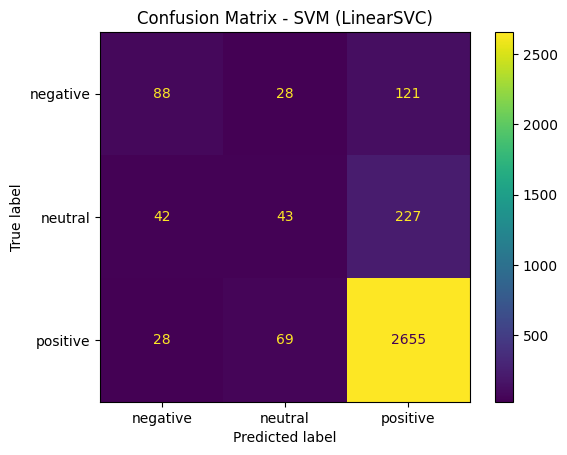

In [12]:
# Cell 10: Confusion Matrix for best model (by Macro F1)
best_model_name = results_df.iloc[0]["Model"]
best_clf = models[best_model_name]

best_pipe = Pipeline([
    ("tfidf", tfidf),
    ("model", best_clf)
])

best_pipe.fit(X_train, y_train)
best_pred = best_pipe.predict(X_test)

cm = confusion_matrix(y_test, best_pred, labels=["negative", "neutral", "positive"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "neutral", "positive"])

plt.figure(figsize=(6,6))
disp.plot(values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


### **Distribution of emotions by place/region**

In [13]:
# Cell 11: Sentiment distribution per place (report-ready)
sent_by_place = (
    data.groupby(["place", "sentiment"])
        .size()
        .reset_index(name="count")
)

pivot = sent_by_place.pivot(index="place", columns="sentiment", values="count").fillna(0).astype(int)
pivot["total"] = pivot.sum(axis=1)
pivot = pivot.sort_values("total", ascending=False)

pivot


sentiment,negative,neutral,positive,total
place,,,,
قرية رجال ألمع التراثية,542,555,3582,4679
القرية الشعبية في الاحساء,244,539,3460,4243
جدة التاريخية,245,280,2811,3336
قصر المصمك,115,166,2467,2748
جبل الفيل1,38,21,1438,1497


In [15]:
! pip install arabic-reshaper python-bidi


In [16]:
# Cell: Arabic text support
import arabic_reshaper
from bidi.algorithm import get_display
from matplotlib import rcParams

# اختيار خط يدعم العربية (متوفر غالبًا في ويندوز)
rcParams['font.family'] = 'Arial'


In [17]:
# Cell: Fix Arabic labels
def fix_arabic(text):
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)
    return bidi_text

pivot_fixed = pivot.copy()
pivot_fixed.index = pivot_fixed.index.map(fix_arabic)


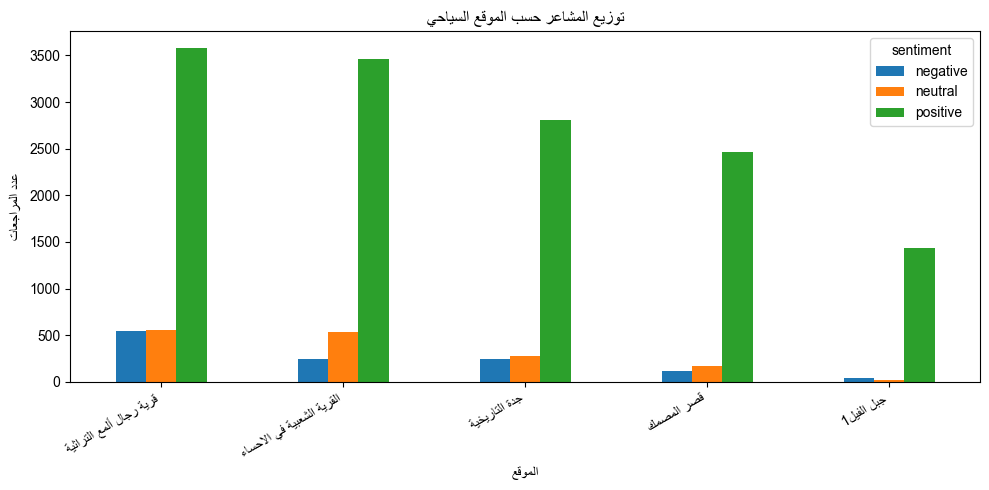

In [ ]:
# Cell : Plot (Arabic labels fixed)
pivot_fixed[["negative", "neutral", "positive"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(fix_arabic("توزيع المشاعر حسب الموقع السياحي"))
plt.xlabel(fix_arabic("الموقع"))
plt.ylabel(fix_arabic("عدد المراجعات"))

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### **Conclusion**

This project applied NLP techniques to analyze the sentiment of tourist reviews from different regions in Saudi Arabia. Using TF-IDF features, three machine learning models—Logistic Regression, Naive Bayes, and SVM—were trained and evaluated. The results demonstrate the effectiveness of sentiment analysis in extracting meaningful insights from tourist feedback and supporting data-driven decisions in the tourism sector.